### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras import layers, models
from PIL import Image
from collections import Counter

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


### 2. PARÁMETROS GLOBALES

In [ ]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 75
NUM_CLASSES   = 10
NOMBRE_MODELO = 'resnet50v2_con_ft'

# Fase 1: Congelación de capas
PATIENCE_ES_F1  = 10
PATIENCE_LR_F1  = 5

# Fase 2: Descongelación de capas
PATIENCE_ES_F2  = 15
PATIENCE_LR_F2  = 8

### 3. PREPROCESAMIENTO

In [3]:
# RUTAS DEL DATASET
base_dir  = '../../../Data/Cana_de_azucar'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

# DATA AUGMENTATION — IGUAL EN TODOS LOS MODELOS
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Dataset de ENTRENAMIENTO
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

# Dataset de VALIDACIÓN
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Dataset de TEST
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Imágenes de entrenamiento : {train_generator.samples}')
print(f'Imágenes de validación    : {val_generator.samples}')
print(f'Imágenes de test          : {test_generator.samples}')

Found 6106 images belonging to 10 classes.
Found 1308 images belonging to 10 classes.
Found 1308 images belonging to 10 classes.
Imágenes de entrenamiento : 6106
Imágenes de validación    : 1308
Imágenes de test          : 1308


### 4. CONSTRUCCIÓN DEL MODELO RESNET50V2

In [4]:
# CARGAR RESNET50V2 CON PESOS DE IMAGENET
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False    # Congelamos para la Fase 1

# CAPAS FINALES PERSONALIZADAS
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name=NOMBRE_MODELO)

### 5. COMPILAR EL MODELO

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "resnet50v2_con_ft"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50v2 (Functional)     (None, 7, 7, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               262272    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 23,828,362
Trainable params: 263,562
Non-trainable params: 23,564,800
_______________________________

### 6. ENTRENAMIENTO — FASE 1 (backbone congelado)

In [ ]:
# ============================================================
# FASE 1: Entrenar solo las capas nuevas (backbone congelado)
# El backbone actúa como extractor de características fijo.
# ============================================================
print('FASE 1: Entrenando cabeza (backbone congelado)')

early_stopping_fase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES_F1,
    restore_best_weights=True,
    verbose=1
)

checkpoint_fase1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_fase1_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True, 
    verbose=1
)

reduce_lr_fase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR_F1,
    min_lr=1e-6,
    verbose=1
)

history_fase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping_fase1, checkpoint_fase1, reduce_lr_fase1]
)

print(f'\nFase 1 completada.')
print(f'Mejor val_accuracy fase 1: {max(history_fase1.history["val_accuracy"]):.4f}')

FASE 1: Entrenando cabeza (backbone congelado)
Epoch 1/75
191/191 [==============================] - ETA: 0s - loss: 1.0828 - accuracy: 0.6417
Epoch 1: val_loss improved from inf to 0.47206, saving model to resnet50v2_con_ft_fase1_weights.h5
191/191 [==============================] - 373s 2s/step - loss: 1.0828 - accuracy: 0.6417 - val_loss: 0.4721 - val_accuracy: 0.8570 - lr: 0.0010
Epoch 2/75
191/191 [==============================] - ETA: 0s - loss: 0.6362 - accuracy: 0.7943
Epoch 2: val_loss improved from 0.47206 to 0.40519, saving model to resnet50v2_con_ft_fase1_weights.h5
191/191 [==============================] - 374s 2s/step - loss: 0.6362 - accuracy: 0.7943 - val_loss: 0.4052 - val_accuracy: 0.8723 - lr: 0.0010
Epoch 3/75
191/191 [==============================] - ETA: 0s - loss: 0.5237 - accuracy: 0.8362
Epoch 3: val_loss improved from 0.40519 to 0.33676, saving model to resnet50v2_con_ft_fase1_weights.h5
191/191 [==============================] - 377s 2s/step - loss: 0.5237

### 7. ENTRENAMIENTO — FASE 2 (fine-tuning)

In [ ]:
# FASE 2: Fine-tuning (descongelar últimas capas del backbone)
# Las primeras capas aprenden cosas generales - las dejamos congeladas.
# Las últimas capas aprenden patrones específicos.

import tensorflow.keras.backend as K

# Paso 1: descongelar todo el backbone
base_model.trainable = True

# Paso 2: volver a congelar las primeras capas, solo descongelamos las últimas 30 capas
CAPAS_A_CONGELAR = len(base_model.layers) - 30

for i, layer in enumerate(base_model.layers):
    if i < CAPAS_A_CONGELAR:
        layer.trainable = False   # primeras capas: congeladas
    else:
        layer.trainable = True    # últimas 30 capas: descongeladas

print('FASE 2: Fine-tuning (últimas 30 capas descongeladas)')
print(f'Total capas en backbone  : {len(base_model.layers)}')
print(f'Capas congeladas         : {CAPAS_A_CONGELAR}')
print(f'Capas descongeladas      : {len(base_model.layers) - CAPAS_A_CONGELAR}')

# Paso 3: solo cambiamos el lr, No recompilamos para preservar el momentum de Adam acumulado en la Fase 1
K.set_value(model.optimizer.learning_rate, 1e-5)

early_stopping_fase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES_F2,          # = 15, igual en todos los modelos
    restore_best_weights=True,
    verbose=1
)

checkpoint_fase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr_fase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR_F2,
    min_lr=1e-6,
    verbose=1
)

history_fase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping_fase2, checkpoint_fase2, reduce_lr_fase2]
)

print(f'\nFase 2 completada.')
print(f'Mejor val_accuracy fase 2: {max(history_fase2.history["val_accuracy"]):.4f}')

FASE 2: Fine-tuning (últimas 30 capas descongeladas)
Total capas en backbone  : 190
Capas congeladas         : 160
Capas descongeladas      : 30
Epoch 1/75
191/191 [==============================] - ETA: 0s - loss: 0.1885 - accuracy: 0.9545
Epoch 1: val_loss improved from inf to 0.17167, saving model to resnet50v2_con_ft_weights.h5
191/191 [==============================] - 525s 3s/step - loss: 0.1885 - accuracy: 0.9545 - val_loss: 0.1717 - val_accuracy: 0.9625 - lr: 1.0000e-05
Epoch 2/75
191/191 [==============================] - ETA: 0s - loss: 0.2000 - accuracy: 0.9525
Epoch 2: val_loss did not improve from 0.17167
191/191 [==============================] - 504s 3s/step - loss: 0.2000 - accuracy: 0.9525 - val_loss: 0.1721 - val_accuracy: 0.9618 - lr: 1.0000e-05
Epoch 3/75
191/191 [==============================] - ETA: 0s - loss: 0.1858 - accuracy: 0.9561
Epoch 3: val_loss improved from 0.17167 to 0.17010, saving model to resnet50v2_con_ft_weights.h5
191/191 [=======================

### 8. CURVAS DE ENTRENAMIENTO (Fase 1 + Fase 2)

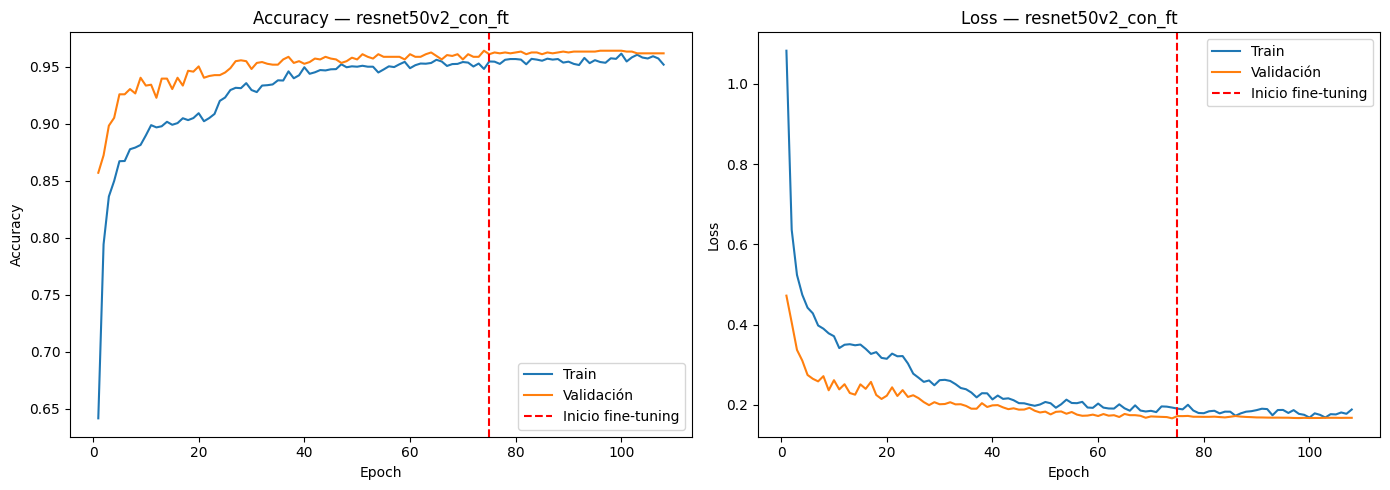


Fase 1 — mejor val_accuracy: 0.9641
Fase 2 — mejor val_accuracy: 0.9641


In [8]:
acc      = history_fase1.history['accuracy']     + history_fase2.history['accuracy']
val_acc  = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']
loss     = history_fase1.history['loss']         + history_fase2.history['loss']
val_loss = history_fase1.history['val_loss']     + history_fase2.history['val_loss']

epochs_total = range(1, len(acc) + 1)
corte        = len(history_fase1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_total, acc,     label='Train')
ax1.plot(epochs_total, val_acc, label='Validación')
ax1.axvline(x=corte, color='red', linestyle='--', label='Inicio fine-tuning')
ax1.set_title(f'Accuracy — {NOMBRE_MODELO}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs_total, loss,     label='Train')
ax2.plot(epochs_total, val_loss, label='Validación')
ax2.axvline(x=corte, color='red', linestyle='--', label='Inicio fine-tuning')
ax2.set_title(f'Loss — {NOMBRE_MODELO}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'\nFase 1 — mejor val_accuracy: {max(history_fase1.history["val_accuracy"]):.4f}')
print(f'Fase 2 — mejor val_accuracy: {max(history_fase2.history["val_accuracy"]):.4f}')

### 9. EVALUACIÓN FINAL EN TEST

In [9]:
# MÉTRICAS SOBRE EL CONJUNTO DE TEST (datos nunca vistos)
test_generator.reset()

# Accuracy y Loss en test
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f'\nTest Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

# Predicciones
predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

# F1 Score
f1 = f1_score(y_true, y_pred, average='weighted')
print(f'F1 Score      : {f1:.4f}')

# Reporte de clasificación (precision, recall, f1 por clase)
print('\n--- Reporte de clasificación ---')
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys(),
    digits=4
))

# Guardar resultados en .txt
with open(f'{NOMBRE_MODELO}_resultados.txt', 'w') as f:
    f.write(f'Modelo        : {NOMBRE_MODELO}\n')
    f.write(f'Test Accuracy : {test_accuracy:.4f}\n')
    f.write(f'Test Loss     : {test_loss:.4f}\n')
    f.write(f'F1 Score      : {f1:.4f}\n\n')
    f.write(f'Fase 1 — mejor val_accuracy: {max(history_fase1.history["val_accuracy"]):.4f}\n')
    f.write(f'Fase 2 — mejor val_accuracy: {max(history_fase2.history["val_accuracy"]):.4f}\n\n')
    f.write('--- Reporte de clasificación ---\n')
    f.write(classification_report(
        y_true,
        y_pred,
        target_names=test_generator.class_indices.keys(),
        digits=4        # ← 4 decimales
    ))

print(f'\nResultados guardados en {NOMBRE_MODELO}_resultados.txt')

41/41 [==============================] - 83s 2s/step - loss: 0.1353 - accuracy: 0.9717

Test Accuracy : 0.9717
Test Loss     : 0.1353
41/41 [==============================] - 84s 2s/step
F1 Score      : 0.9718

--- Reporte de clasificación ---
                  precision    recall  f1-score   support

          carbon     1.0000    1.0000    1.0000        75
   hoja_amarilla     0.9730    0.9600    0.9664       150
   mancha_anillo     1.0000    1.0000    1.0000       105
    mancha_parda     0.9733    0.9733    0.9733       150
         mosaico     0.9800    0.9800    0.9800       150
     muermo_rojo     0.9226    0.9533    0.9377       150
            roya     0.9533    0.9533    0.9533       150
           sanas     0.9603    0.9667    0.9635       150
           secas     0.9873    1.0000    0.9936        78
tizon_bacteriano     1.0000    0.9667    0.9831       150

        accuracy                         0.9717      1308
       macro avg     0.9750    0.9753    0.9751      1308


### 10. MATRIZ DE CONFUSIÓN

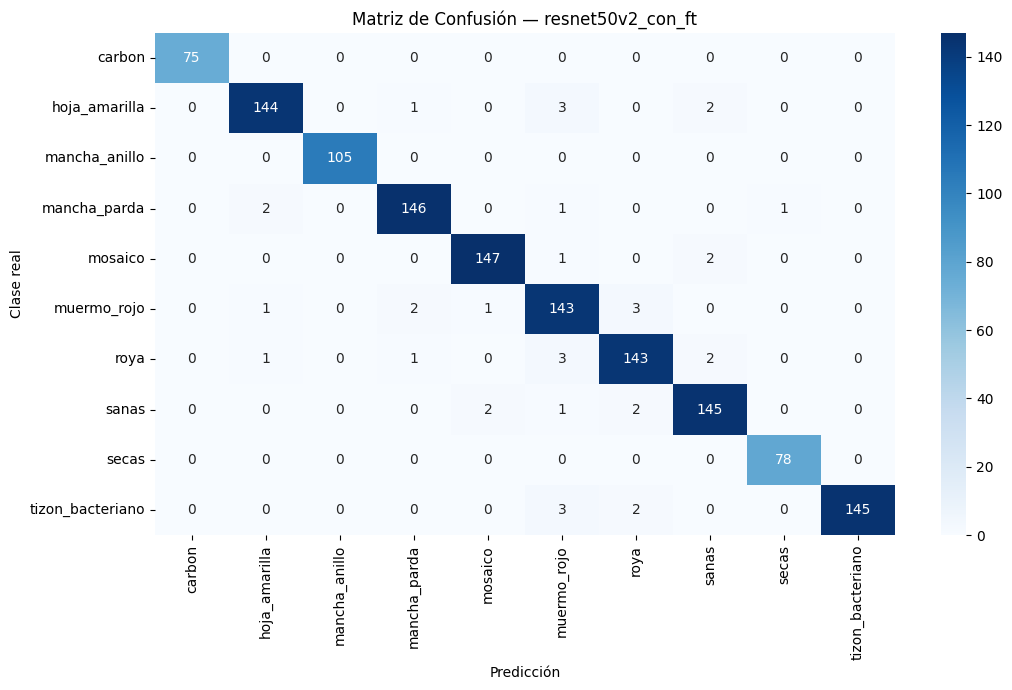

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(11, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_generator.class_indices.keys(),
    yticklabels=test_generator.class_indices.keys()
)
plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title(f'Matriz de Confusión — {NOMBRE_MODELO}')
plt.tight_layout()
plt.show()

### 11. IMÁGENES CLASIFICADAS INCORRECTAMENTE

In [ ]:
test_generator.reset()
filenames = test_generator.filenames

incorrectas = np.where(y_pred != y_true)[0]
class_indices  = test_generator.class_indices
indice_a_clase = {v: k for k, v in class_indices.items()}

pares        = [(indice_a_clase[y_true[i]], indice_a_clase[y_pred[i]]) for i in incorrectas]
conteo_pares = Counter(pares)

UMBRAL           = 1
pares_relevantes = {par for par, count in conteo_pares.items() if count >= UMBRAL}

print('Pares con 1 o más confusiones:')
for par, count in sorted(conteo_pares.items(), key=lambda x: -x[1]):
    if count >= UMBRAL:
        print(f'  {par[0]} → {par[1]}: {count} imágenes')

indices_filtrados = [
    i for i in incorrectas
    if (indice_a_clase[y_true[i]], indice_a_clase[y_pred[i]]) in pares_relevantes
]
print(f'\nTotal de imágenes a mostrar: {len(indices_filtrados)}')

base_dir = '../../../Data/Cana_de_azucar/test'

for par in sorted(pares_relevantes, key=lambda p: -conteo_pares[p]):
    clase_real, clase_predicha = par
    indices_par = [
        i for i in indices_filtrados
        if indice_a_clase[y_true[i]] == clase_real
        and indice_a_clase[y_pred[i]] == clase_predicha
    ]
    n_mostrar = len(indices_par)
    n_cols    = 5
    n_filas   = (n_mostrar + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(20, n_filas * 4))
    axes = axes.flatten()
    for j, idx in enumerate(indices_par):
        ruta_imagen = os.path.join(base_dir, filenames[idx])
        img = Image.open(ruta_imagen)
        axes[j].imshow(img)
        axes[j].set_title(
            f'Real: {clase_real}\nPredicha: {clase_predicha}',
            fontsize=9, color='red'
        )
        axes[j].axis('off')
    for j in range(n_mostrar, len(axes)):
        axes[j].axis('off')
    plt.suptitle(
        f'{clase_real} → {clase_predicha}  ({n_mostrar} imágenes)',
        fontsize=14, fontweight='bold', y=1.02
    )
    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

Pares con 5 o más confusiones:

Total de imágenes a mostrar: 0


### 12. GUARDAR PESOS DEL MODELO

In [12]:
model.save_weights(f'{NOMBRE_MODELO}_weights.h5')
print(f'Pesos guardados como: {NOMBRE_MODELO}_weights.h5')

Pesos guardados como: resnet50v2_con_ft_weights.h5
